# EDA — Istanbul Customer Shopping Dataset
**Ciencia de Datos I · ETITC · 2026**  
Daniel Valencia · Daniel Medcalfe

Este notebook realiza el Análisis Exploratorio de Datos (EDA) completo sobre el dataset de compras en 10 centros comerciales de Estambul (2021–2023).

In [8]:
# ── Librerías ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

print("✅ Librerías cargadas")

✅ Librerías cargadas


## 1. Carga del dataset

In [9]:
df_raw = pd.read_csv('../../data/raw/customer_shopping_data.csv')
print(f"Filas    : {df_raw.shape[0]:,}")
print(f"Columnas : {df_raw.shape[1]}")
df_raw.head()

Filas    : 99,457
Columnas : 10


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


## 2. Inspección inicial

In [10]:
print("=== TIPOS DE DATOS ===")
df_raw.info()
print()
print("=== VALORES NULOS ===")
print(df_raw.isnull().sum())
print()
print("=== DUPLICADOS ===")
print(f"Filas duplicadas: {df_raw.duplicated().sum()}")

=== TIPOS DE DATOS ===
<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  str    
 1   customer_id     99457 non-null  str    
 2   gender          99457 non-null  str    
 3   age             99457 non-null  int64  
 4   category        99457 non-null  str    
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  str    
 8   invoice_date    99457 non-null  str    
 9   shopping_mall   99457 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 7.6 MB

=== VALORES NULOS ===
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

=== DUPLICADOS ===
Filas duplicadas: 0


## 3. Limpieza y preparación

In [11]:
df = df_raw.copy()

# Fechas
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)
df['year']         = df['invoice_date'].dt.year
df['month']        = df['invoice_date'].dt.month
df['day_of_week']  = df['invoice_date'].dt.day_name()

# Gasto total
df['total_spend'] = (df['price'] * df['quantity']).round(2)

# Outliers en price (IQR)
Q1, Q3 = df['price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df['is_price_outlier'] = (df['price'] < Q1 - 1.5*IQR) | (df['price'] > Q3 + 1.5*IQR)

# Tipos categóricos
for col in ['gender','category','payment_method','shopping_mall']:
    df[col] = df[col].astype('category')

print(f"✅ Dataset limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"   Rango de fechas: {df['invoice_date'].min().date()} → {df['invoice_date'].max().date()}")
print(f"   Outliers en price: {df['is_price_outlier'].sum():,} ({df['is_price_outlier'].mean()*100:.1f}%)")

✅ Dataset limpio: 99,457 filas × 15 columnas
   Rango de fechas: 2021-01-01 → 2023-03-08
   Outliers en price: 5,024 (5.1%)


## 4. Estadísticas descriptivas

In [12]:
df[['age','quantity','price','total_spend']].describe().round(2)

,age,quantity,price,total_spend
count,99457.00,99457.00,99457.00,99457.00
mean,43.43,3.00,689.26,2528.79
std,14.99,1.41,941.18,4222.48
min,18.00,1.00,5.23,5.23
25%,30.00,2.00,45.45,136.35
50%,43.00,3.00,203.30,600.17
75%,56.00,4.00,1200.32,2700.72
max,69.00,5.00,5250.00,26250.00


## 5. Distribuciones univariadas

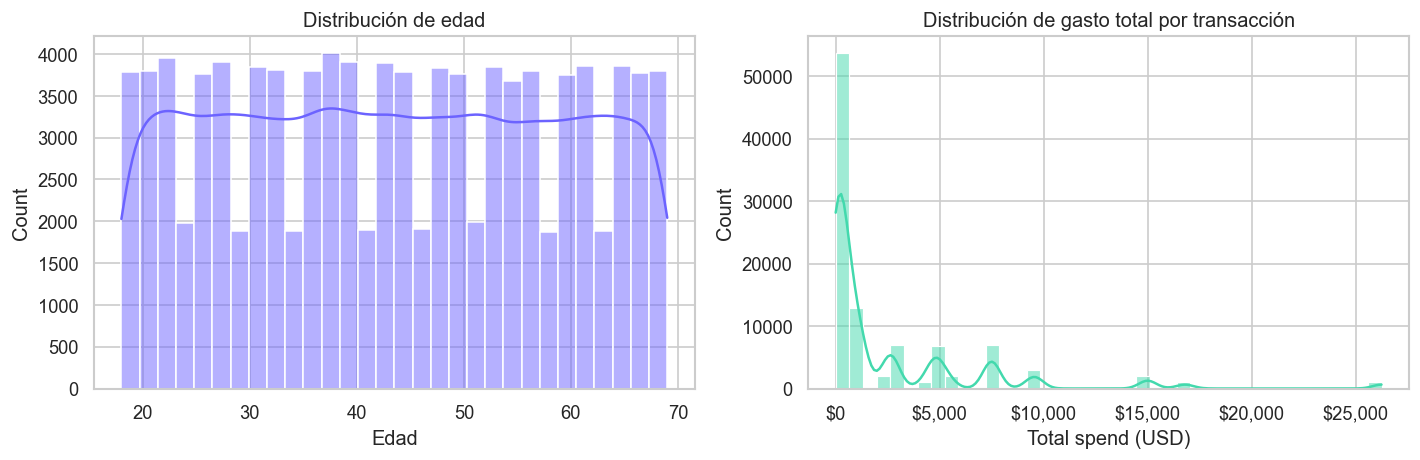

✅ Guardada: reports/figures/dist_edad_gasto.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Edad
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color='#6C63FF')
axes[0].set_title('Distribución de edad')
axes[0].set_xlabel('Edad')

# Gasto total
sns.histplot(df['total_spend'], bins=40, kde=True, ax=axes[1], color='#43D9AD')
axes[1].set_title('Distribución de gasto total por transacción')
axes[1].set_xlabel('Total spend (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../../reports/figures/dist_edad_gasto.png', bbox_inches='tight')
plt.show()
print("✅ Guardada: reports/figures/dist_edad_gasto.png")

## 6. Ingresos por categoría

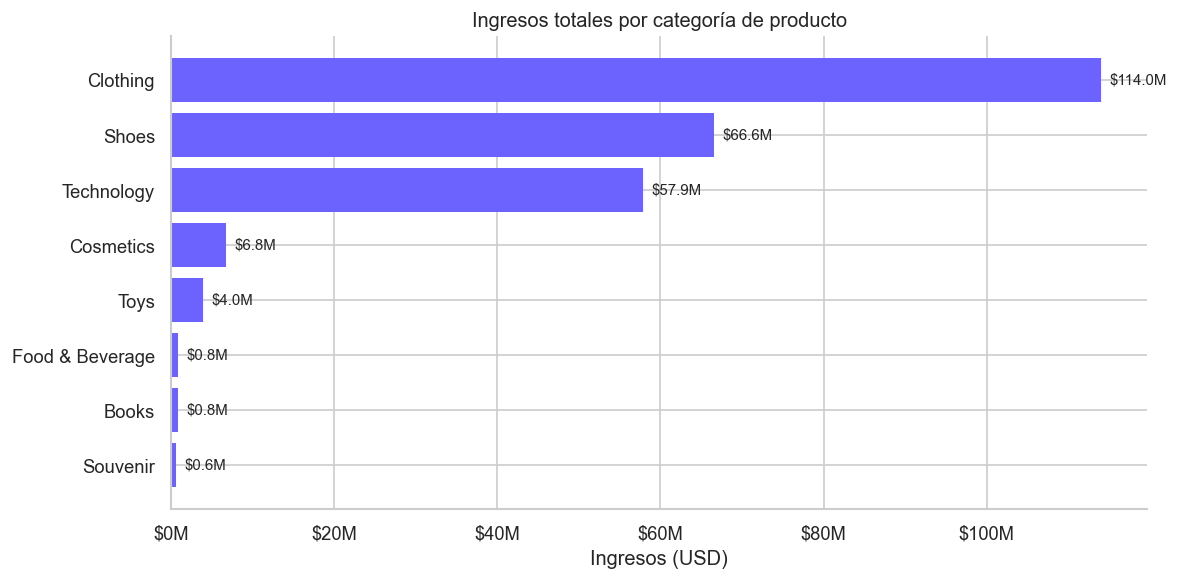

In [14]:
ingresos_cat = (
    df.groupby('category', observed=True)['total_spend']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(ingresos_cat.index, ingresos_cat.values, color='#6C63FF', edgecolor='none')
ax.bar_label(bars, labels=[f'${v/1e6:.1f}M' for v in ingresos_cat.values], padding=5, fontsize=9)
ax.set_title('Ingresos totales por categoría de producto')
ax.set_xlabel('Ingresos (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../../reports/figures/ingresos_categoria.png', bbox_inches='tight')
plt.show()

## 7. Distribución por género

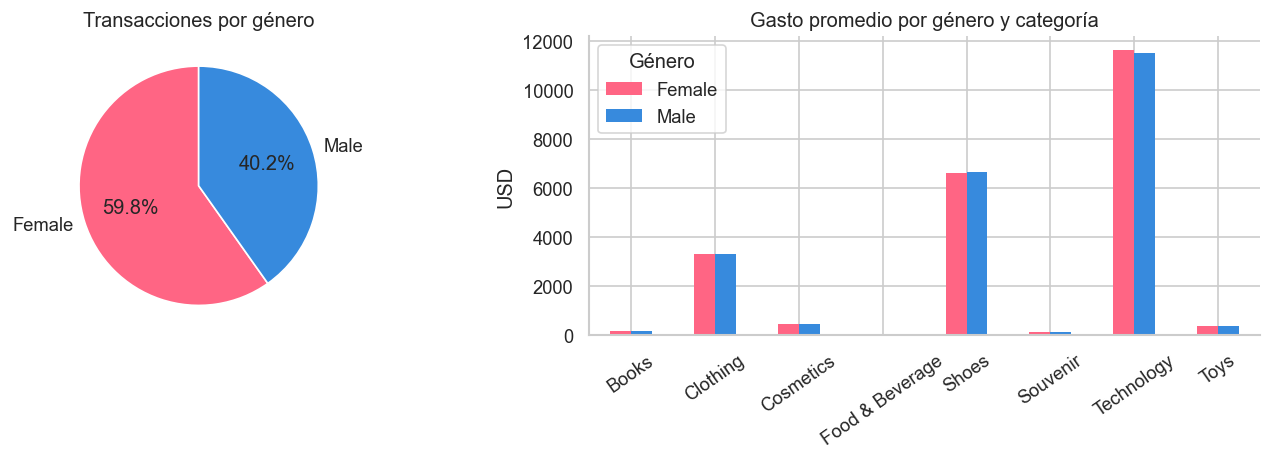

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
gen = df['gender'].value_counts()
axes[0].pie(gen.values, labels=gen.index, autopct='%1.1f%%',
            colors=['#FF6584','#378ADD'], startangle=90)
axes[0].set_title('Transacciones por género')

# Gasto promedio por género y categoría
pivot = df.groupby(['gender','category'], observed=True)['total_spend'].mean().unstack()
pivot.T.plot(kind='bar', ax=axes[1], color=['#FF6584','#378ADD'], edgecolor='none')
axes[1].set_title('Gasto promedio por género y categoría')
axes[1].set_xlabel('')
axes[1].set_ylabel('USD')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(title='Género')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../../reports/figures/distribucion_genero.png', bbox_inches='tight')
plt.show()

## 8. Métodos de pago

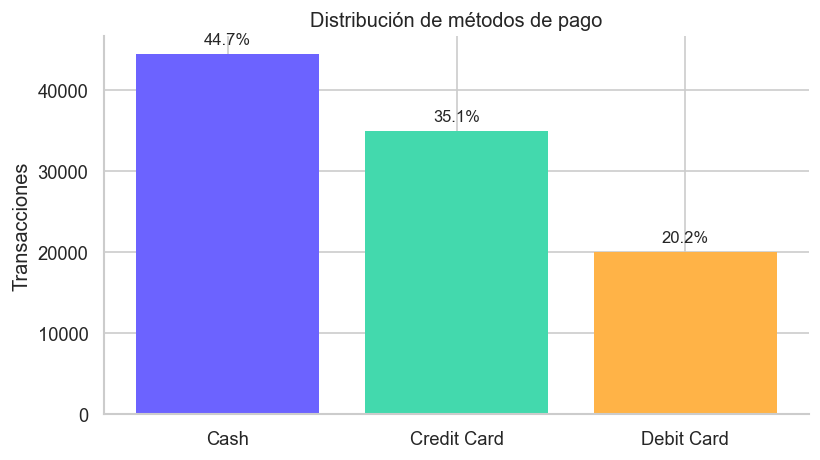

In [16]:
pago = df['payment_method'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(pago.index, pago.values, color=['#6C63FF','#43D9AD','#FFB347'], edgecolor='none')
ax.bar_label(bars, labels=[f'{v/len(df)*100:.1f}%' for v in pago.values], padding=4, fontsize=10)
ax.set_title('Distribución de métodos de pago')
ax.set_ylabel('Transacciones')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../../reports/figures/metodos_pago.png', bbox_inches='tight')
plt.show()

## 9. Ingresos por centro comercial

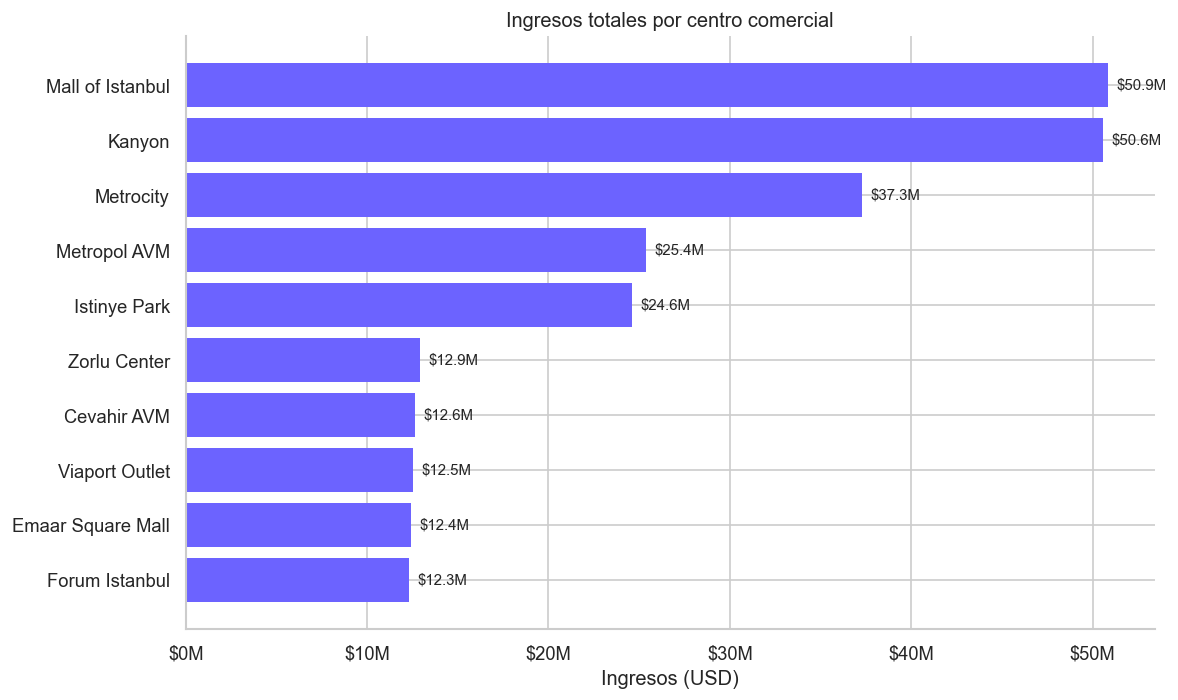

In [17]:
mall_ing = (
    df.groupby('shopping_mall', observed=True)['total_spend']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(mall_ing.index, mall_ing.values, color='#6C63FF', edgecolor='none')
ax.bar_label(bars, labels=[f'${v/1e6:.1f}M' for v in mall_ing.values], padding=5, fontsize=9)
ax.set_title('Ingresos totales por centro comercial')
ax.set_xlabel('Ingresos (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../../reports/figures/ingresos_mall.png', bbox_inches='tight')
plt.show()

## 10. Tendencia temporal de ingresos (2021–2023)

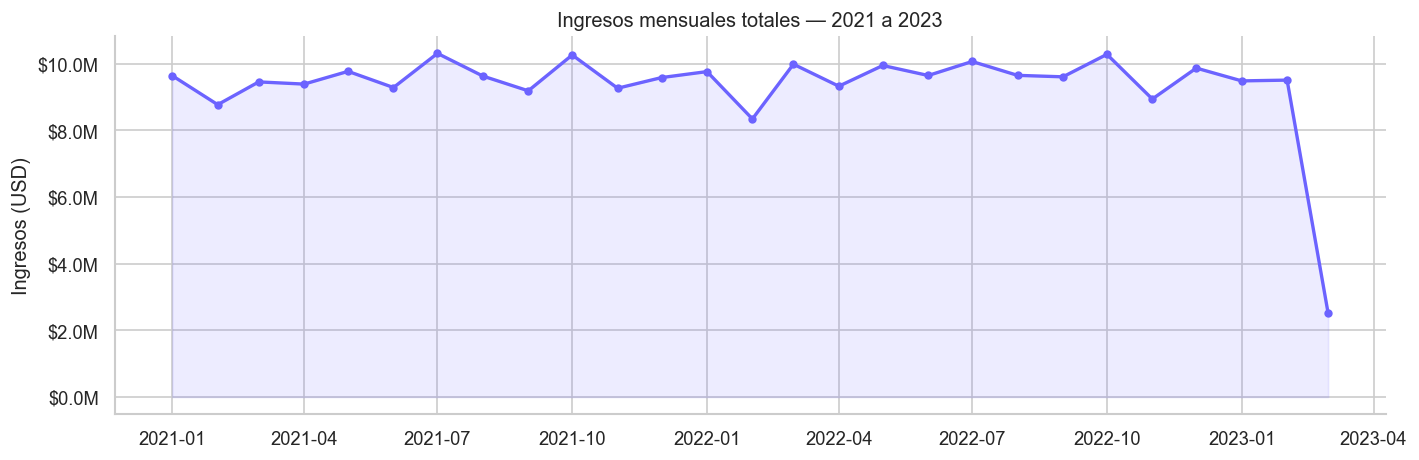

In [18]:
temporal = (
    df.groupby(['year','month'])['total_spend']
    .sum()
    .reset_index()
)
temporal['periodo'] = pd.to_datetime(
    temporal['year'].astype(str) + '-' + temporal['month'].astype(str) + '-01'
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(temporal['periodo'], temporal['total_spend'], color='#6C63FF', linewidth=2, marker='o', markersize=4)
ax.fill_between(temporal['periodo'], temporal['total_spend'], alpha=0.12, color='#6C63FF')
ax.set_title('Ingresos mensuales totales — 2021 a 2023')
ax.set_xlabel('')
ax.set_ylabel('Ingresos (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../../reports/figures/tendencia_temporal.png', bbox_inches='tight')
plt.show()

## 11. Correlación entre variables numéricas

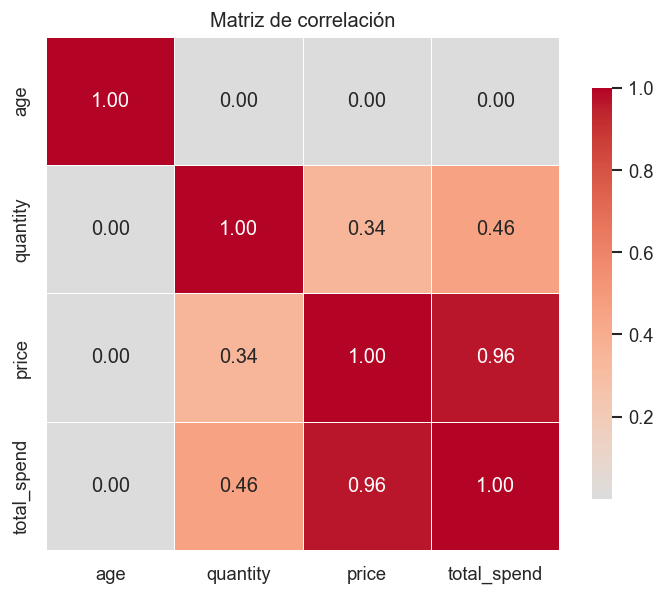

In [19]:
corr = df[['age','quantity','price','total_spend']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.savefig('../../reports/figures/correlacion.png', bbox_inches='tight')
plt.show()

## 12. Análisis de outliers en price

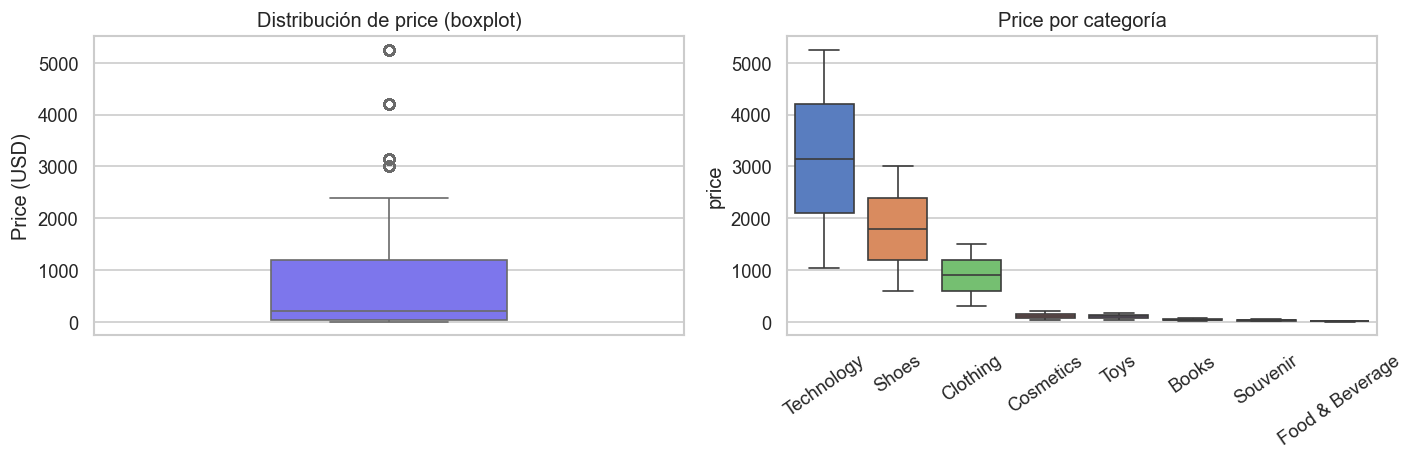

Outliers marcados: 5,024 (5.1%)
→ No se eliminan: pueden ser compras legítimas de tecnología o ropa premium


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot general
sns.boxplot(y=df['price'], ax=axes[0], color='#6C63FF', width=0.4)
axes[0].set_title('Distribución de price (boxplot)')
axes[0].set_ylabel('Price (USD)')

# Por categoría
sns.boxplot(data=df, x='category', y='price', ax=axes[1],
            palette='muted', order=df.groupby('category', observed=True)['price'].median().sort_values(ascending=False).index)
axes[1].set_title('Price por categoría')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('../../reports/figures/outliers_price.png', bbox_inches='tight')
plt.show()

print(f"Outliers marcados: {df['is_price_outlier'].sum():,} ({df['is_price_outlier'].mean()*100:.1f}%)")
print("→ No se eliminan: pueden ser compras legítimas de tecnología o ropa premium")

## 13. Resumen de hallazgos

In [21]:
print("=" * 55)
print("HALLAZGOS CLAVE DEL EDA")
print("=" * 55)

top_cat = df.groupby('category', observed=True)['total_spend'].sum().idxmax()
top_mall = df.groupby('shopping_mall', observed=True)['total_spend'].sum().idxmax()
pct_fem = (df['gender'] == 'Female').mean() * 100

print(f"  Dataset          : {len(df):,} transacciones · 10 malls · 2021-2023")
print(f"  Categoría top    : {top_cat}")
print(f"  Mall top         : {top_mall}")
print(f"  % Clientes fem.  : {pct_fem:.1f}%")
print(f"  Edad promedio    : {df['age'].mean():.1f} años")
print(f"  Ticket promedio  : ${df['total_spend'].mean():,.0f}")
print(f"  Ticket máximo    : ${df['total_spend'].max():,.0f}")
print(f"  Outliers price   : {df['is_price_outlier'].sum():,} ({df['is_price_outlier'].mean()*100:.1f}%)")
print()
print("Gráficas guardadas en reports/figures/")
print("Dataset listo para Módulo 1 — Segmentación K-Means")

HALLAZGOS CLAVE DEL EDA
  Dataset          : 99,457 transacciones · 10 malls · 2021-2023
  Categoría top    : Clothing
  Mall top         : Mall of Istanbul
  % Clientes fem.  : 59.8%
  Edad promedio    : 43.4 años
  Ticket promedio  : $2,529
  Ticket máximo    : $26,250
  Outliers price   : 5,024 (5.1%)

Gráficas guardadas en reports/figures/
Dataset listo para Módulo 1 — Segmentación K-Means
